In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import os
import torch.nn.functional as F
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import pickle
import torch.nn as nn
import matplotlib.pyplot as plt



df = pd.read_csv("employee_absenteeism_1000.csv")

### Models

In [20]:
class LSTMClassifier_S(nn.Module):
    def __init__(
        self,
        input_dim=23,          # Option B: number of features
        hidden_dim=64,
        num_layers=1,
        bidirectional=False,
        output_dim=1,          # 1 for binary
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.output_dim = output_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )

        num_directions = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * num_directions, output_dim)

    def forward(self, x):
        """
        Option B input handling:
          - accepts x as (batch, input_dim) from your DataLoader
          - or (batch, 1, input_dim)
        internally ensures shape (batch, 1, input_dim) for LSTM
        """

        # (batch, input_dim) -> (batch, 1, input_dim)
        if x.dim() == 2:
            x = x.unsqueeze(1)

        # x: (batch, seq_len=1, input_dim)
        _, (hn, _) = self.lstm(x)
        # hn: (num_layers * num_directions, batch, hidden_dim)

        if self.bidirectional:
            last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)  # (batch, hidden_dim*2)
        else:
            last_hidden = hn[-1]  # (batch, hidden_dim)

        logits = self.fc(last_hidden)  # (batch, output_dim)

        if self.output_dim == 1:
            logits = logits.squeeze(1)  # (batch,)

        return logits

   



class CNNClassifier_S(nn.Module):
    def __init__(
        self,
        input_dim=23,         # Option B: 23 values per sample
        output_dim=1,         # 1 for binary, >1 for multi-label
        channels=(32, 64),    # conv channels
        kernel_size=3,
        dropout=0.3,
        use_batchnorm=True,
    ):
        """
        CNN classifier for Option B input:
          - input from loader: (B, 23)
          - interpreted as 1D signal length=23 with 1 channel
          - Conv1d expects: (B, C_in, L)

        Output:
          - (B,) if output_dim == 1
          - (B, output_dim) otherwise
        """
        super().__init__()
        self.output_dim = output_dim
        self.input_dim = input_dim

        c1, c2 = channels
        padding = kernel_size // 2  # keep length roughly same

        layers = []

        # Block 1
        layers.append(nn.Conv1d(in_channels=1, out_channels=c1, kernel_size=kernel_size, padding=padding))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(c1))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))

        # Block 2
        layers.append(nn.Conv1d(in_channels=c1, out_channels=c2, kernel_size=kernel_size, padding=padding))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(c2))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))

        self.conv = nn.Sequential(*layers)

        # Pool across length dimension -> fixed vector (B, c2)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Final classifier
        self.fc = nn.Linear(c2, output_dim)

    def forward(self, x):
        """
        Accepts:
          - x: (B, 23)
          - or x: (B, 1, 23)

        Conv1d input must be (B, C_in, L)
        """
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (B, 1, 23)

        # conv features
        x = self.conv(x)         # (B, c2, L)
        x = self.pool(x).squeeze(-1)  # (B, c2)

        logits = self.fc(x)      # (B, output_dim)
        if self.output_dim == 1:
            logits = logits.squeeze(1)  # (B,)

        return logits



class LSTM_FCN_Classifier(nn.Module):
    def __init__(
        self,
        input_dim,                 # length L (e.g., 11, 23, ...)
        output_dim=1,
        conv_channels=(128, 256, 128),
        kernel_sizes=(5, 5, 5),
        lstm_hidden=128,
        lstm_layers=1,
        dropout=0.3,
        use_batchnorm=True,
        activation="relu",
    ):
        """
        Exact LSTM-FCN adapted to "vector as sequence":

        Input from loader:
          - (B, L)  OR  (B, 1, L)

        CNN/FCN branch:
          (B, 1, L)
            -> Conv(128)+BN+ReLU
            -> Conv(256)+BN+ReLU
            -> Conv(128)+BN+ReLU
            -> GlobalAvgPool -> (B, 128)

        LSTM branch:
          (B, 1, L) -> transpose -> (B, L, 1)
            -> LSTM(input_size=1)
            -> Dropout
            -> last hidden state -> (B, H)

        Concat -> Linear -> logits
        """
        super().__init__()
        self.output_dim = output_dim
        self.input_dim = input_dim

        if isinstance(kernel_sizes, int):
            kernel_sizes = (kernel_sizes, kernel_sizes, kernel_sizes)
        assert len(kernel_sizes) == 3
        assert len(conv_channels) == 3

        act = nn.ReLU() if activation.lower() == "relu" else nn.GELU()

        c1, c2, c3 = conv_channels
        k1, k2, k3 = kernel_sizes

        def conv_block(in_ch, out_ch, k):
            padding = k // 2  # "same-ish" to avoid kernel issues on short L
            block = [nn.Conv1d(in_ch, out_ch, kernel_size=k, padding=padding, stride=1)]
            if use_batchnorm:
                block.append(nn.BatchNorm1d(out_ch))
            block.append(act)
            return nn.Sequential(*block)

        # CNN branch expects (B, 1, L)
        self.cnn1 = conv_block(1, c1, k1)
        self.cnn2 = conv_block(c1, c2, k2)
        self.cnn3 = conv_block(c2, c3, k3)
        self.cnn_pool = nn.AdaptiveAvgPool1d(1)  # GAP -> (B, c3, 1)

        # LSTM branch expects (B, L, 1) so input_size=1
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.lstm_dropout = nn.Dropout(dropout)

        # Fusion
        self.fc = nn.Linear(c3 + lstm_hidden, output_dim)

    def forward(self, x):
        # Accept (B, L) or (B, 1, L)
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (B, 1, L)
        elif x.dim() != 3:
            raise ValueError(f"Expected x dim 2 or 3, got {x.dim()}")

        # CNN/FCN branch: (B, 1, L)
        z = self.cnn1(x)
        z = self.cnn2(z)
        z = self.cnn3(z)
        cnn_feat = self.cnn_pool(z).squeeze(-1)  # (B, c3)

        # LSTM branch: (B, 1, L) -> (B, L, 1)
        x_lstm = x.transpose(1, 2)               # (B, L, 1)
        _, (h_n, _) = self.lstm(x_lstm)
        lstm_feat = self.lstm_dropout(h_n[-1])   # (B, H)

        feat = torch.cat([lstm_feat, cnn_feat], dim=1)  # (B, H + c3)
        logits = self.fc(feat)

        if self.output_dim == 1:
            logits = logits.squeeze(1)
        return logits


### Loss Function

In [21]:
class BinaryFocalLossWithLogits(nn.Module):
    """
    Binary focal loss that accepts logits.
    Works for shapes (N,), (N,T), (N,C), etc. Targets must be 0/1 floats.
    
    alpha: weight for class 1 (positive). If None, no alpha balancing.
           You can also pass a tuple (alpha0, alpha1) if you prefer.
    gamma: focusing parameter (>=0). Common: 2.0.
    reduction: 'mean' | 'sum' | 'none'
    """
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets, mask=None):
        targets = targets.float()

        # BCE per element (no reduction)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        # p = sigmoid(logits)
        p = torch.sigmoid(logits)

        # p_t = p if y=1 else (1-p)
        p_t = p * targets + (1 - p) * (1 - targets)

        # focal factor = (1 - p_t)^gamma
        focal_factor = (1 - p_t).clamp(min=1e-12).pow(self.gamma)

        loss = focal_factor * bce

        # Optional alpha balancing
        if self.alpha is not None:
            if isinstance(self.alpha, (tuple, list)):
                alpha0, alpha1 = self.alpha
                alpha_t = alpha1 * targets + alpha0 * (1 - targets)
            else:
                # alpha means weight for class 1; (1-alpha) for class 0
                alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

            loss = alpha_t * loss

        # Optional mask for padded sequences
        if mask is not None:
            loss = loss * mask.float()
            denom = mask.float().sum().clamp(min=1.0)
        else:
            denom = loss.numel()

        if self.reduction == "mean":
            return loss.sum() / denom
        elif self.reduction == "sum":
            return loss.sum()
        elif self.reduction == "none":
            return loss
        else:
            raise ValueError(f"Unknown reduction: {self.reduction}")




class SoftGMeanLossWithLogits(nn.Module):
    """
    Differentiable approximation to maximizing G-Mean = sqrt(TPR * TNR).

    Uses soft counts computed from probabilities (no thresholding):
      TP = sum(p * y)
      FN = sum((1-p) * y)
      TN = sum((1-p) * (1-y))
      FP = sum(p * (1-y))

    Then:
      TPR = TP / (TP + FN)
      TNR = TN / (TN + FP)
      G   = sqrt(TPR * TNR)

    Loss = -log(G) (default) or 1-G
    """
    def __init__(self, eps: float = 1e-12, use_log: bool = True):
        super().__init__()
        self.eps = eps
        self.use_log = use_log

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        y = targets.type_as(logits)
        p = torch.sigmoid(logits)

        # micro over all elements (binary or multilabel)
        p = p.reshape(-1)
        y = y.reshape(-1)

        tp = (p * y).sum()
        fn = ((1 - p) * y).sum()
        tn = ((1 - p) * (1 - y)).sum()
        fp = (p * (1 - y)).sum()

        tpr = tp / (tp + fn + self.eps)
        tnr = tn / (tn + fp + self.eps)

        g = torch.sqrt(tpr * tnr + self.eps)

        if self.use_log:
            return -torch.log(g + self.eps)
        else:
            return 1.0 - g


In [22]:
def make_attendance_timeseries_with_bg(
    df_att,
    df_bg,
    id_col="ID",
    window_size=7,
    label_size=1,
    x_prefix="D",
    y_prefix="Y",
    return_y_array=True,
    split_by_user=True,
    train_ratio=0.6,
    val_ratio=0.2,
    test_ratio=0.2,
    random_state=42,
):
    """
    Build time-series windows from attendance data, join background features,
    and (optionally) split into train/val/test grouped by user.

    - Background features appear first in X.
    - User ID is NOT included in returned X arrays.
    - When split_by_user=True, windows from the same user are kept in the same split.

    Returns
    -------
    If split_by_user is False:
        X : np.ndarray of shape (n_samples, n_features)
        y : np.ndarray or pandas object (depending on return_y_array and label_size)

    If split_by_user is True:
        X_train, y_train, X_val, y_val, X_test, y_test
        (each X_* is np.ndarray, each y_* is np.ndarray if return_y_array=True)
    """

    if label_size < 1:
        raise ValueError("label_size must be at least 1")

    # --- 1. Build sliding windows per user ---

    date_cols = [c for c in df_att.columns if c != id_col]

    X_rows = []
    y_rows = []

    for _, row in df_att.iterrows():
        uid = row[id_col]
        seq = row[date_cols].to_numpy()

        # Find first non-2 value (first valid attendance day)
        non2_mask = seq != 2
        if not np.any(non2_mask):
            continue

        first_valid = np.argmax(non2_mask)
        last_start = len(seq) - window_size - label_size
        if first_valid > last_start:
            continue

        for start in range(first_valid, last_start + 1):
            window = seq[start : start + window_size + label_size]

            # Reject any windows containing "2"
            if 2 in window:
                continue

            x_vals = window[:window_size]
            y_vals = window[window_size : window_size + label_size]

            X_rows.append([uid, *x_vals])
            y_rows.append(y_vals.tolist())

    # If no windows created, bail out early
    if len(X_rows) == 0:
        raise ValueError("No valid windows could be created from the input data.")

    # --- 2. Build temporary DataFrame for X (attendance part) ---

    att_cols = [id_col] + [f"{x_prefix}{i+1}" for i in range(window_size)]
    X_att = pd.DataFrame(X_rows, columns=att_cols)

    # --- 3. Build y (full, unsplit) ---

    if label_size == 1:
        y = pd.Series([row[0] for row in y_rows], name=f"{y_prefix}1")
        if return_y_array:
            y = y.to_numpy()
    else:
        y_cols = [f"{y_prefix}{i+1}" for i in range(label_size)]
        y = pd.DataFrame(y_rows, columns=y_cols)
        if return_y_array:
            y = y.to_numpy()

    # --- 4. Merge background data (one record per user) ---

    df_bg_clean = df_bg.drop_duplicates(subset=[id_col])
    X = X_att.merge(df_bg_clean, on=id_col, how="left")

    # Reorder: [User ID] + background + attendance window
    bg_cols = [c for c in df_bg_clean.columns if c != id_col]
    att_cols = [f"{x_prefix}{i+1}" for i in range(window_size)]
    X = X[[id_col] + bg_cols + att_cols]

    # Keep user_ids for grouped split
    user_ids = X[id_col].to_numpy()

    # --- 5. If not splitting, just drop User ID and return full X,y ---

    if not split_by_user:
        X = X.drop(columns=[id_col])
        X = X.to_numpy()
        return X, y

    # --- 6. Grouped split by User ID (Option B) ---

    unique_users = np.unique(user_ids)
    rng = np.random.default_rng(random_state)
    shuffled_users = rng.permutation(unique_users)

    n_users = len(shuffled_users)
    n_train = int(n_users * train_ratio)
    n_val = int(n_users * val_ratio)
    # remainder goes to test
    n_test = n_users - n_train - n_val

    users_train = shuffled_users[:n_train]
    users_val   = shuffled_users[n_train:n_train + n_val]
    users_test  = shuffled_users[n_train + n_val:]

    train_mask = np.isin(user_ids, users_train)
    val_mask   = np.isin(user_ids, users_val)
    test_mask  = np.isin(user_ids, users_test)

    # Drop User ID before converting to numpy
    X_no_id = X.drop(columns=[id_col])

    X_train = X_no_id[train_mask].to_numpy()
    X_val   = X_no_id[val_mask].to_numpy()
    X_test  = X_no_id[test_mask].to_numpy()

    # y might be np.ndarray, Series, or DataFrame – boolean mask works in all cases
    y_train = y[train_mask]
    y_val   = y[val_mask]
    y_test  = y[test_mask]

    # Ensure y_* are numpy arrays if requested
    if return_y_array:
        y_train = np.asarray(y_train)
        y_val   = np.asarray(y_val)
        y_test  = np.asarray(y_test)

    return X_train, y_train, X_val, y_val, X_test, y_test

def model_name_gen_with_bg(window_size, output_size, model, batch_size):
    return f"models_garden/{window_size}_days_to_predict_{output_size}_days_{model.__class__.__name__}_{batch_size}_bs.pt"



def scale_selected_columns(X, cols=(0,1,2,3,4,10,11,12)):
    """
    Standard-scale selected columns of X.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
    cols : tuple of int
        Column indices to scale

    Returns
    -------
    X_scaled : np.ndarray
        Copy of X with selected columns standardised
    scaler : StandardScaler
        Fitted scaler (useful for inverse transform or test data)
    """
    X = np.asarray(X)
    X_scaled = X.copy()

    scaler = StandardScaler()
    X_scaled[:, cols] = scaler.fit_transform(X[:, cols])

    return X_scaled, scaler

def _f1_from_counts(tp: int, fp: int, fn: int, tn:int , eps: float = 1e-12):
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    fpr = fp / (fp + tn + eps)
    return precision, recall, f1, fpr

def _macro_f1_from_class_counts(tp_c: torch.Tensor, fp_c: torch.Tensor, fn_c: torch.Tensor, tn_c: torch.Tensor, eps: float = 1e-12):
    # tp_c/fp_c/fn_c are shape (C,) on CPU
    precision_c = tp_c / (tp_c + fp_c + eps)
    recall_c    = tp_c / (tp_c + fn_c + eps)
    f1_c        = 2 * precision_c * recall_c / (precision_c + recall_c + eps)
    fpr_c       = fp_c / (fp_c + tn_c + eps)
    return (
        precision_c.mean().item(),
        recall_c.mean().item(),
        f1_c.mean().item(),
        fpr_c.mean().item(),
    )

def _f1_macro_from_counts(tp_c, fp_c, fn_c, tn_c, eps=1e-12):
    # tp_c/fp_c/fn_c shape (C,)
    precision_c = tp_c / (tp_c + fp_c + eps)
    recall_c    = tp_c / (tp_c + fn_c + eps)
    f1_c        = 2 * precision_c * recall_c / (precision_c + recall_c + eps)
    fpr_c       = fp_c / (fp_c + tn_c + eps)
    return precision_c.mean().item(), recall_c.mean().item(), f1_c.mean().item(), fpr_c.mean().item()
    


def train_or_load_model(
    model,
    train_loader,
    val_loader,
    save_path,
    epochs=50,
    lr=1e-3,
    device=None,
    pos_weight=None,          # float tensor: scalar (binary) or shape (output_dim,)
    early_stop_patience=8,
    min_delta=0.0,
    threshold=0.5,            # for multi-label predictions
    epoch_freq=5,
    loss_function = SoftGMeanLossWithLogits(use_log=True)
):
    """
    Supports:
      - output_dim == 1: binary classification (labels shape (B,))
      - output_dim > 1: multi-label classification (labels shape (B, C)), e.g. [1,0,1]
        using BCEWithLogitsLoss and sigmoid thresholding.

    Accuracy reported:
      - For output_dim == 1: standard accuracy
      - For output_dim > 1:
          * micro_acc  = element-wise accuracy over all labels
          * subset_acc = exact match accuracy (all labels correct per sample)
    """



    # You had this in your code; keeping it as-is.
    # save_path = model_name_gen(window_size, output_size, model, batch_size)

    device = device or ("cuda" if torch.cuda.is_available() else "mps")
    model = model.to(device)

    # Where we will store the losses
    loss_save_path = save_path.replace(".pt", "_losses.pkl")

    # ---- load if exists ----
    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt)
        model.eval()
        print(f"Loaded existing model from: {save_path}")

        # Try to load loss history too
        if os.path.exists(loss_save_path):
            with open(loss_save_path, "rb") as f:
                history = pickle.load(f)
        else:
            history = {"train_loss": [], "val_loss": []}

        return model, history

    if val_loader is None:
        raise ValueError("val_loader is required for early stopping.")

    # Infer output_dim from the model (works because you store it)
    output_dim = getattr(model, "output_dim", None)
    if output_dim is None:
        raise ValueError("Model must have attribute `output_dim` (as in your LSTMClassifier).")



    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    patience_left = early_stop_patience

    # ---- loss history ----
    history = {"train_loss": [], "val_loss": []}

    # ---- training loop ----
    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        train_loss_sum = 0.0
        train_total_samples = 0

        # accumulators for metrics
        if output_dim == 1:
            train_tp = train_fp = train_tn = train_fn = 0
        else:
            train_tp = train_fp = train_tn = train_fn = 0
            train_tp_c = torch.zeros(output_dim, device="cpu")
            train_fp_c = torch.zeros(output_dim, device="cpu")
            train_tn_c = torch.zeros(output_dim, device="cpu")
            train_fn_c = torch.zeros(output_dim, device="cpu")

        for inputs, labels in train_loader:
            inputs = inputs.to(device)

            if output_dim == 1:
                labels = labels.to(device).float()
            else:
                labels = labels.to(device).float()

            optimizer.zero_grad()
            logits = model(inputs)

            # Keeping your current behavior:
            # You overwrite criterion with SoftGMeanLossWithLogits.
            criterion = loss_function
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            bs = inputs.size(0)
            train_loss_sum += loss.item() * bs
            train_total_samples += bs

            # metrics
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs >= threshold).long()
                y = labels.long()

                if output_dim == 1:
                    train_tp += ((preds == 1) & (y == 1)).sum().item()
                    train_fp += ((preds == 1) & (y == 0)).sum().item()
                    train_tn += ((preds == 0) & (y == 0)).sum().item()
                    train_fn += ((preds == 0) & (y == 1)).sum().item()
                else:
                    train_tp += ((preds == 1) & (y == 1)).sum().item()
                    train_fp += ((preds == 1) & (y == 0)).sum().item()
                    train_tn += ((preds == 0) & (y == 0)).sum().item()
                    train_fn += ((preds == 0) & (y == 1)).sum().item()

                    tp_c = ((preds == 1) & (y == 1)).sum(dim=0).to("cpu")
                    fp_c = ((preds == 1) & (y == 0)).sum(dim=0).to("cpu")
                    tn_c = ((preds == 0) & (y == 0)).sum(dim=0).to("cpu")
                    fn_c = ((preds == 0) & (y == 1)).sum(dim=0).to("cpu")
                    train_tp_c += tp_c
                    train_fp_c += fp_c
                    train_tn_c += tn_c
                    train_fn_c += fn_c

        train_loss = train_loss_sum / max(train_total_samples, 1)
        train_precision, train_recall, train_f1, train_fpr = _f1_from_counts(
            train_tp, train_fp, train_fn, train_tn
        )

        if output_dim > 1:
            train_precision_macro, train_recall_macro, train_f1_macro, train_fpr_macro = _f1_macro_from_counts(
                train_tp_c, train_fp_c, train_fn_c, train_tn_c
            )

        # ---- validate ----
        model.eval()
        val_loss_sum = 0.0
        val_total_samples = 0

        if output_dim == 1:
            val_tp = val_fp = val_tn = val_fn = 0
        else:
            val_tp = val_fp = val_tn = val_fn = 0
            val_tp_c = torch.zeros(output_dim, device="cpu")
            val_fp_c = torch.zeros(output_dim, device="cpu")
            val_tn_c = torch.zeros(output_dim, device="cpu")
            val_fn_c = torch.zeros(output_dim, device="cpu")

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)

                if output_dim == 1:
                    labels = labels.to(device).float()
                else:
                    labels = labels.to(device).float()

                logits = model(inputs)

                # Keeping your current behavior:
                criterion = loss_function
                loss = criterion(logits, labels)

                bs = inputs.size(0)
                val_loss_sum += loss.item() * bs
                val_total_samples += bs

                probs = torch.sigmoid(logits)
                preds = (probs >= threshold).long()
                y = labels.long()

                if output_dim == 1:
                    val_tp += ((preds == 1) & (y == 1)).sum().item()
                    val_fp += ((preds == 1) & (y == 0)).sum().item()
                    val_tn += ((preds == 0) & (y == 0)).sum().item()
                    val_fn += ((preds == 0) & (y == 1)).sum().item()
                else:
                    val_tp += ((preds == 1) & (y == 1)).sum().item()
                    val_fp += ((preds == 1) & (y == 0)).sum().item()
                    val_tn += ((preds == 0) & (y == 0)).sum().item()
                    val_fn += ((preds == 0) & (y == 1)).sum().item()

                    tp_c = ((preds == 1) & (y == 1)).sum(dim=0).to("cpu")
                    fp_c = ((preds == 1) & (y == 0)).sum(dim=0).to("cpu")
                    tn_c = ((preds == 0) & (y == 0)).sum(dim=0).to("cpu")
                    fn_c = ((preds == 0) & (y == 1)).sum(dim=0).to("cpu")
                    val_tp_c += tp_c
                    val_fp_c += fp_c
                    val_tn_c += tn_c
                    val_fn_c += fn_c

        val_loss = val_loss_sum / max(val_total_samples, 1)
        val_precision, val_recall, val_f1, val_fpr = _f1_from_counts(
            val_tp, val_fp, val_fn, val_tn
        )

        if output_dim > 1:
            val_precision_macro, val_recall_macro, val_f1_macro, val_fpr_macro = _f1_macro_from_counts(
                val_tp_c, val_fp_c, val_fn_c, val_tn_c
            )

        # ---- record losses ----
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # ---- early stopping check ----
        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            patience_left = early_stop_patience

            os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
            torch.save(model.state_dict(), save_path)

            # Save loss history whenever we save a new best model
            with open(loss_save_path, "wb") as f:
                pickle.dump(history, f)

            best_tag = " (saved best)"
        else:
            patience_left -= 1
            best_tag = ""

        # ---- logging ----
        if epoch % epoch_freq == 0:
            if output_dim == 1:
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={train_loss:.4f}, train_f1={train_f1:.4f}, train_fpr={train_fpr:.4f} (P={train_precision:.4f}, R={train_recall:.4f}) | "
                    f"val_loss={val_loss:.4f}, val_f1={val_f1:.4f}, val_fpr={val_fpr:.4f} (P={val_precision:.4f}, R={val_recall:.4f}) | "
                    f"patience_left={patience_left}{best_tag}"
                )
            else:
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={train_loss:.4f}, train_micro_f1={train_f1:.4f}, train_micro_fpr={train_fpr:.4f} | "
                    f"val_loss={val_loss:.4f}, val_micro_f1={val_f1:.4f}, val_micro_fpr={val_fpr:.4f} | "
                    f"patience_left={patience_left}{best_tag}"
                )

        if patience_left <= 0:
            print(f"Early stopping triggered. Best val_loss={best_val_loss:.4f}")
            break

    # ---- load best weights before returning ----
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    # Ensure losses are saved at the end too (even if last epoch didn't improve)
    os.makedirs(os.path.dirname(loss_save_path) or ".", exist_ok=True)
    with open(loss_save_path, "wb") as f:
        pickle.dump(history, f)

    return model, history


def evaluate_on_test(
    model,
    test_loader,
    device=None,
    threshold=0.5,
    pos_weight=None,
    show_samples=10,
    use_focal=True,             # keep consistent with training if you used focal
    focal_alpha=(0.75, 0.25),
    focal_gamma=2.0,
    report_macro_f1=True,       # for multi-label: also report macro F1
):

    device = device or ("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
    model = model.to(device)
    model.eval()

    output_dim = getattr(model, "output_dim", None)
    if output_dim is None:
        raise ValueError("Model must have attribute `output_dim`.")

    # loss
    if use_focal:
        # assumes BinaryFocalLossWithLogits is defined (as in your training code)
        criterion = BinaryFocalLossWithLogits(alpha=focal_alpha, gamma=focal_gamma, reduction="mean")

    else:
        if pos_weight is not None:
            pos_weight = pos_weight.to(device)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        else:
            criterion = nn.BCEWithLogitsLoss()

    test_loss_sum = 0.0
    total_samples = 0

    # F1 accumulators
    tp = fp = tn = fn = 0
    if output_dim > 1 and report_macro_f1:
        tp_c = torch.zeros(output_dim, device="cpu")
        fp_c = torch.zeros(output_dim, device="cpu")
        tn_c = torch.zeros(output_dim, device="cpu")
        fn_c = torch.zeros(output_dim, device="cpu")

    all_logits = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)

            if output_dim == 1:
                labels = labels.to(device).float().view(-1)   # (B,)
            else:
                labels = labels.to(device).float()            # (B, C)

            logits = model(inputs)
            if output_dim == 1 and logits.dim() > 1:
                logits = logits.view(-1)                      # ensure (B,)
            
            criterion = SoftGMeanLossWithLogits(use_log=True)
            loss = criterion(logits, labels)

            bs = inputs.size(0)
            test_loss_sum += loss.item() * bs
            total_samples += bs

            # ---- predictions + F1 counts ----
            probs = torch.sigmoid(logits)

            if output_dim == 1:
                preds = (probs >= threshold).long()           # (B,)
                y = labels.long()

                tp += ((preds == 1) & (y == 1)).sum().item()
                fp += ((preds == 1) & (y == 0)).sum().item()
                tn += ((preds == 0) & (y == 0)).sum().item()
                fn += ((preds == 0) & (y == 1)).sum().item()

            else:
                preds = (probs >= threshold).long()           # (B, C)
                y = labels.long()

                # micro (global) counts across all labels
                tp += ((preds == 1) & (y == 1)).sum().item()
                fp += ((preds == 1) & (y == 0)).sum().item()
                tn += ((preds == 0) & (y == 0)).sum().item()
                fn += ((preds == 0) & (y == 1)).sum().item()

                # macro per-class counts (optional)
                if report_macro_f1:
                    tp_c += ((preds == 1) & (y == 1)).sum(dim=0).to("cpu")
                    fp_c += ((preds == 1) & (y == 0)).sum(dim=0).to("cpu")
                    tn_c += ((preds == 0) & (y == 0)).sum(dim=0).to("cpu")
                    fn_c += ((preds == 0) & (y == 1)).sum(dim=0).to("cpu")

            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())
            all_preds.append(preds.detach().cpu())

    # ---- aggregate outputs ----
    test_loss = test_loss_sum / max(total_samples, 1)
    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_preds = torch.cat(all_preds, dim=0)

    # ---- metrics ----
    precision, recall, f1, fpr = _f1_from_counts(tp, fp, fn, tn)

    metrics = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

    if output_dim > 1 and report_macro_f1:
        precision_macro, recall_macro, f1_macro, fpr_macro = _macro_f1_from_class_counts(tp_c, fp_c, fn_c, tn_c)
        metrics.update({
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
            "fpr_macro": fpr_macro,
        })


    return test_loss, metrics, all_preds, all_labels, all_logits



def confusion_counts_binary(
    preds: torch.Tensor,
    targets: torch.Tensor,
    mask: torch.Tensor,
):
    """
    preds, targets: 0/1 int tensors, same shape (N,), (N,T), (N,C)...
    mask: same shape, 1 for valid elements, 0 for ignore/pad
    """
    preds = preds.to(torch.int64)
    targets = targets.to(torch.int64)

    if mask is None:
        mask = torch.ones_like(targets, dtype=torch.int64)
    else:
        mask = mask.to(torch.int64)

    # valid elements only
    preds = preds[mask == 1]
    targets = targets[mask == 1]

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()
    tn = ((preds == 0) & (targets == 0)).sum().item()
    return tp, fp, fn, tn


def f1_scores(tp, fp, fn, tn, eps: float = 1e-12):
    # Class 1
    f1_1 = (2 * tp) / (2 * tp + fp + fn + eps)

    # Class 0 (treat 0 as positive)
    f1_0 = (2 * tn) / (2 * tn + fn + fp + eps)

    return f1_0, f1_1


def evaluate_binary(
    preds: torch.Tensor,
    targets: torch.Tensor,
    mask = None,
):
    tp, fp, fn, tn = confusion_counts_binary(preds, targets, mask=mask)

    eps = 1e-12

    # For class 1
    precision_1 = tp / (tp + fp + eps)
    recall_1    = tp / (tp + fn + eps)

    # For class 0 (treat 0 as positive)
    precision_0 = tn / (tn + fn + eps)  # predicted 0 that are truly 0
    recall_0    = tn / (tn + fp + eps)  # how many true 0 caught

    f1_0, f1_1 = f1_scores(tp, fp, fn, tn, eps=eps)

    # Balanced accuracy = (TPR_1 + TPR_0)/2 = (recall_1 + recall_0)/2
    bal_acc = 0.5 * (recall_1 + recall_0)

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    specificity = 1 - fpr

    return precision_1, f1_1, specificity, bal_acc 

def sweep_window_size_with_gb(model_func):

    result_path = f"models_garden/{model_func.__name__}_results.pkl"

    if os.path.exists(result_path):
        with open(result_path, "rb") as f:
            results = pickle.load(f)
        return results
    
    else:

        results = {}

        for i in [5 * (2 ** k) for k in range(10) if 5 * (2 ** k) <= 300]:

            window_size = i
            output_size = 5
            batch_size = 1024

            X_train, y_train, X_val, y_val, X_test, y_test = make_attendance_timeseries_with_bg(attendence_encoded_df, cat_encoded_df, window_size=window_size, label_size=output_size)

            scaled_X_train, scaled_X_train_scaler = scale_selected_columns(X_train)
            scaled_X_val, scaled_X_val_scaler = scale_selected_columns(X_val)
            scaled_X_test, scaled_X_test_scaler = scale_selected_columns(X_test)

            train_dataset = TimeSeriesDataset(scaled_X_train, y_train)
            val_dataset   = TimeSeriesDataset(scaled_X_val,   y_val)
            test_dataset  = TimeSeriesDataset(scaled_X_test,  y_test)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
            test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

            model = model_func(input_dim=len(X_train[0]), output_dim=output_size)


            trained_model, training_history = train_or_load_model(
                model,
                train_loader=train_loader,
                val_loader=val_loader,
                save_path= model_name_gen_with_bg(window_size, output_size, model, batch_size),
                threshold=0.5,
                epochs=100,
                lr=1e-3,
                early_stop_patience=10,
                min_delta=1e-4
            )

            test_loss, test_metrics,  all_preds, all_labels, all_logits = evaluate_on_test(trained_model,test_loader=val_loader)
            precision, f1, specificity, bal_acc = evaluate_binary(all_preds, all_labels)

            results[i] = {"history": training_history, "precision": precision, "f1": f1, "specificity":specificity, "bal_acc": bal_acc}
        
        with open(result_path, "wb") as f:
            pickle.dump(results, f)

        return results


def plot_metrics_vs_window(results: dict, title="Effect of window size on metrics", x_label_name = "Window Size"):

    rows = []
    for w, d in results.items():
        rows.append({
            x_label_name: int(w),
            "precision": d.get("precision"),
            "f1": d.get("f1"),
            "specificity": d.get("specificity"),
            "bal_acc": d.get("bal_acc"),
        })

    df = pd.DataFrame(rows).sort_values(x_label_name)

    plt.figure()
    plt.plot(df[x_label_name], df["precision"], marker="o", label="precision")
    plt.plot(df[x_label_name], df["f1"], marker="o", label="f1")
    plt.plot(df[x_label_name], df["specificity"], marker="o", label="specificity")
    plt.plot(df[x_label_name], df["bal_acc"], marker="o", label="bal_acc")
    plt.xlabel(x_label_name)
    plt.ylabel("Metric value")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

def make_attendance_timeseries_without_bg(
    df_att,
    id_col="ID",
    window_size=7,
    label_size=1,
    x_prefix="D",
    y_prefix="Y",
    return_y_array=True,
    split_by_user=True,
    train_ratio=0.6,
    val_ratio=0.2,
    test_ratio=0.2,
    random_state=42,
):
    """
    Build sliding windows from attendance-only data (no background merge),
    and optionally split train/val/test by user ID (grouped split).

    Input:
      df_att: columns = [ID, day1, day2, ..., dayN]
    """

    if label_size < 1:
        raise ValueError("label_size must be at least 1")
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + val_ratio + test_ratio must sum to 1.0")

    date_cols = [c for c in df_att.columns if c != id_col]

    X_rows, y_rows = [], []

    for _, row in df_att.iterrows():
        uid = row[id_col]
        seq = row[date_cols].to_numpy()

        non2_mask = seq != 2
        if not np.any(non2_mask):
            continue

        first_valid = int(np.argmax(non2_mask))
        last_start = len(seq) - window_size - label_size
        if first_valid > last_start:
            continue

        for start in range(first_valid, last_start + 1):
            window = seq[start : start + window_size + label_size]
            if 2 in window:
                continue

            x_vals = window[:window_size]
            y_vals = window[window_size : window_size + label_size]

            X_rows.append([uid, *x_vals])
            y_rows.append(y_vals.tolist())

    if len(X_rows) == 0:
        raise ValueError("No valid windows could be created from the input data.")

    # Build X dataframe (keep ID for split)
    x_cols = [id_col] + [f"{x_prefix}{i+1}" for i in range(window_size)]
    X = pd.DataFrame(X_rows, columns=x_cols)
    user_ids = X[id_col].to_numpy()

    # Build y
    if label_size == 1:
        y = pd.Series([r[0] for r in y_rows], name=f"{y_prefix}1")
        if return_y_array:
            y = y.to_numpy()
    else:
        y_cols = [f"{y_prefix}{i+1}" for i in range(label_size)]
        y = pd.DataFrame(y_rows, columns=y_cols)
        if return_y_array:
            y = y.to_numpy()

    # No splitting: return all windows (drop ID from X)
    if not split_by_user:
        X = X.drop(columns=[id_col]).to_numpy()
        return X, y

    # Grouped split by user
    unique_users = np.unique(user_ids)
    rng = np.random.default_rng(random_state)
    shuffled_users = rng.permutation(unique_users)

    n_users = len(shuffled_users)
    n_train = int(n_users * train_ratio)
    n_val = int(n_users * val_ratio)

    users_train = shuffled_users[:n_train]
    users_val = shuffled_users[n_train:n_train + n_val]
    users_test = shuffled_users[n_train + n_val:]

    train_mask = np.isin(user_ids, users_train)
    val_mask = np.isin(user_ids, users_val)
    test_mask = np.isin(user_ids, users_test)

    X_no_id = X.drop(columns=[id_col])

    X_train = X_no_id[train_mask].to_numpy()
    X_val = X_no_id[val_mask].to_numpy()
    X_test = X_no_id[test_mask].to_numpy()

    y_train = y[train_mask]
    y_val = y[val_mask]
    y_test = y[test_mask]

    if return_y_array:
        y_train = np.asarray(y_train)
        y_val = np.asarray(y_val)
        y_test = np.asarray(y_test)

    return X_train, y_train, X_val, y_val, X_test, y_test


def model_name_gen_without_bg(window_size, output_size, model, batch_size):
    return f"models_garden/T_{window_size}_days_to_predict_{output_size}_days_{model.__class__.__name__}_{batch_size}_bs.pt"

def model_name_gen_without_bg_loss(window_size, output_size, model, batch_size, loss_function):
    return f"models_garden/T_{window_size}_days_to_predict_{output_size}_days_{model.__class__.__name__}_{batch_size}_bs_{loss_function.__class__.__name__}.pt"

def sweep_window_size_without_bg(model_func):

    result_path = f"models_garden/T_{model_func.__name__}_results.pkl"

    if os.path.exists(result_path):
        with open(result_path, "rb") as f:
            results = pickle.load(f)
        return results
    
    else:

        results = {}

        for i in [5 * (2 ** k) for k in range(10) if 5 * (2 ** k) <= 300]:

            window_size = i
            output_size = 5
            batch_size = 1024

            X_train, y_train, X_val, y_val, X_test, y_test = make_attendance_timeseries_without_bg(attendence_encoded_df, window_size=window_size, label_size=output_size)

            train_dataset = TimeSeriesDataset(X_train, y_train)
            val_dataset   = TimeSeriesDataset(X_val,   y_val)
            test_dataset  = TimeSeriesDataset(X_test,  y_test)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
            test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

            model = model_func(input_dim=len(X_train[0]), output_dim=output_size)


            trained_model, training_history = train_or_load_model(
                model,
                train_loader=train_loader,
                val_loader=val_loader,
                save_path= model_name_gen_without_bg(window_size, output_size, model, batch_size),
                threshold=0.5,
                epochs=100,
                lr=1e-3,
                early_stop_patience=10,
                min_delta=1e-4
            )

            test_loss, test_metrics,  all_preds, all_labels, all_logits = evaluate_on_test(trained_model,test_loader=val_loader)
            precision, f1, specificity, bal_acc = evaluate_binary(all_preds, all_labels)

            results[i] = {"history": training_history, "precision": precision, "f1": f1, "specificity":specificity, "bal_acc": bal_acc}
        
        with open(result_path, "wb") as f:
            pickle.dump(results, f)

        return results



def extract_metrics_df(results_dict: dict, label: str = "results") -> pd.DataFrame:
    rows = []
    for w, d in results_dict.items():
        rows.append({
            "model": label,
            "window_size": int(w),
            "precision": d.get("precision"),
            "f1": d.get("f1"),
            "specificity": d.get("specificity"),
            "bal_acc": d.get("bal_acc"),
        })
    return pd.DataFrame(rows).sort_values(["model", "window_size"])


def plot_metrics_2x2(
    results_list,
    labels=None,
    title="Metrics vs window size"
):
    """
    2x2 subplots with legend at the bottom and axis labels shown everywhere.
    """
    if labels is None:
        labels = [f"run_{i}" for i in range(len(results_list))]
    if len(labels) != len(results_list):
        raise ValueError("labels must match length of results_list")

    df_all = pd.concat(
        [extract_metrics_df(r, label=l) for r, l in zip(results_list, labels)],
        ignore_index=True
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

    metrics = [
        ("precision",   (0, 0), "Precision"),
        ("f1",          (0, 1), "F1-score"),
        ("specificity", (1, 0), "Specificity"),
        ("bal_acc",     (1, 1), "Balanced Accuracy"),
    ]

    for metric, (r, c), metric_title in metrics:
        ax = axes[r, c]
        for lab in labels:
            d = df_all[df_all["model"] == lab].sort_values("window_size")
            ax.plot(
                d["window_size"],
                d[metric],
                marker="o",
                linewidth=2,
                label=lab,
            )

        ax.set_title(metric_title)
        ax.set_xlabel("Window size")
        ax.set_ylabel(metric_title)
        ax.grid(True)
        ax.tick_params(axis="both", labelsize=10)

    # Single legend at the bottom
    handles, leg_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        leg_labels,
        loc="lower center",
        ncol=len(labels),
        frameon=False,
        fontsize=11,
    )

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

    return df_all


def sweep_batch_size_without_bg(model_func):

    result_path = f"models_garden/T_{model_func.__name__}_batch_test_results.pkl"

    if os.path.exists(result_path):
        with open(result_path, "rb") as f:
            results = pickle.load(f)
        return results
    
    else:

        results = {}

        for i in [16 * (2 ** k) for k in range(10) if 16 * (2 ** k) <= 1200]:

            window_size = 20
            output_size = 5
            batch_size = i

            X_train, y_train, X_val, y_val, X_test, y_test = make_attendance_timeseries_without_bg(attendence_encoded_df, window_size=window_size, label_size=output_size)

            train_dataset = TimeSeriesDataset(X_train, y_train)
            val_dataset   = TimeSeriesDataset(X_val,   y_val)
            test_dataset  = TimeSeriesDataset(X_test,  y_test)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
            test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

            model = model_func(input_dim=len(X_train[0]), output_dim=output_size)


            trained_model, training_history = train_or_load_model(
                model,
                train_loader=train_loader,
                val_loader=val_loader,
                save_path= model_name_gen_without_bg(window_size, output_size, model, batch_size),
                threshold=0.5,
                epochs=100,
                lr=1e-3,
                early_stop_patience=10,
                min_delta=1e-4
            )

            test_loss, test_metrics,  all_preds, all_labels, all_logits = evaluate_on_test(trained_model,test_loader=val_loader)
            precision, f1, specificity, bal_acc = evaluate_binary(all_preds, all_labels)

            results[i] = {"history": training_history, "precision": precision, "f1": f1, "specificity":specificity, "bal_acc": bal_acc}
        
        with open(result_path, "wb") as f:
            pickle.dump(results, f)

        return results


def loss_function_test_without_bg(model_func):

    result_path = f"models_garden/T_{model_func.__name__}_focal_loss_soft_g_results.pkl"

    if os.path.exists(result_path):
        with open(result_path, "rb") as f:
            results = pickle.load(f)
        return results
    
    else:

        results = {}

        for i in [BinaryFocalLossWithLogits(alpha=0.75), SoftGMeanLossWithLogits(use_log=True)]:

            window_size = 20
            output_size = 5
            batch_size = 1024

            X_train, y_train, X_val, y_val, X_test, y_test = make_attendance_timeseries_without_bg(attendence_encoded_df, window_size=window_size, label_size=output_size)

            train_dataset = TimeSeriesDataset(X_train, y_train)
            val_dataset   = TimeSeriesDataset(X_val,   y_val)
            test_dataset  = TimeSeriesDataset(X_test,  y_test)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
            test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

            model = model_func(input_dim=len(X_train[0]), output_dim=output_size)


            trained_model, training_history = train_or_load_model(
                model,
                train_loader=train_loader,
                val_loader=val_loader,
                save_path= model_name_gen_without_bg_loss(window_size, output_size, model, batch_size, i),
                threshold=0.5,
                epochs=100,
                lr=1e-3,
                early_stop_patience=10,
                min_delta=1e-4,
                loss_function=i
            )

            test_loss, test_metrics,  all_preds, all_labels, all_logits = evaluate_on_test(trained_model,test_loader=val_loader)
            precision, f1, specificity, bal_acc = evaluate_binary(all_preds, all_labels)

            results[i.__class__.__name__] = {"history": training_history, "precision": precision, "f1": f1, "specificity":specificity, "bal_acc": bal_acc}
        
        with open(result_path, "wb") as f:
            pickle.dump(results, f)

        return results



def final_testing(model_func, window_size_input):

    result_path = f"models_garden/T_{window_size_input}_day_{model_func.__name__}_final_testing_results.pkl"

    if os.path.exists(result_path):
        with open(result_path, "rb") as f:
            results = pickle.load(f)
        return results

    else:

        # results = {}

        window_size = window_size_input
        output_size = 5
        batch_size = 1024

        X_train, y_train, X_val, y_val, X_test, y_test = make_attendance_timeseries_with_bg(attendence_encoded_df, cat_encoded_df, window_size=window_size, label_size=output_size)

        scaled_X_train, scaled_X_train_scaler = scale_selected_columns(X_train)
        scaled_X_val, scaled_X_val_scaler = scale_selected_columns(X_val)
        scaled_X_test, scaled_X_test_scaler = scale_selected_columns(X_test)

        train_dataset = TimeSeriesDataset(scaled_X_train, y_train)
        val_dataset   = TimeSeriesDataset(scaled_X_val,   y_val)
        test_dataset  = TimeSeriesDataset(scaled_X_test,  y_test)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        model = model_func(input_dim=len(X_train[0]), output_dim=output_size)


        trained_model, training_history = train_or_load_model(
            model,
            train_loader=train_loader,
            val_loader=val_loader,
            save_path= model_name_gen_with_bg(window_size, output_size, model, batch_size),
            threshold=0.5,
            epochs=100,
            lr=1e-3,
            early_stop_patience=10,
            min_delta=1e-4
        )

        test_loss, test_metrics,  all_preds, all_labels, all_logits = evaluate_on_test(trained_model,test_loader=test_loader)
        precision, f1, specificity, bal_acc = evaluate_binary(all_preds, all_labels)
        results = {"history": training_history, "precision": precision, "f1": f1, "specificity":specificity, "bal_acc": bal_acc}

        with open(result_path, "wb") as f:
                pickle.dump(results, f)
    
        return results

def find_the_record_by_window(window_size, labels, results_list):
    rows = []

    for model_label, model_results in zip(labels, results_list):
        if window_size in model_results:
            metrics = model_results[window_size]
            rows.append({
                "Model": model_label,
                "Precision": metrics["precision"],
                "F1-Score": metrics["f1"],
                "Specificity": metrics["specificity"],
                "Balanced Accuracy": metrics["bal_acc"]
            })


    return pd.DataFrame(rows)
    

def find_the_record_by_loss_func(t_lstm_fcn_model_loss_func_test_results):

    rows = []

    for model_name, metrics in t_lstm_fcn_model_loss_func_test_results.items():
        rows.append({
            "Loss Function": model_name,
            "Precision": metrics.get("precision"),
            "F1": metrics.get("f1"),
            "Specificity": metrics.get("specificity"),
            "Balanced Accuracy": metrics.get("bal_acc"),
        })

    return pd.DataFrame(rows)


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [23]:
os.makedirs("models_garden", exist_ok=True)

cat_cols = ['Transportation_expense', 'Distance_from_Residence_to_Work',
       'Service_time', 'Age', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index']

cat_encoded_df = df[ ['ID'] + cat_cols]
cat_encoded_df = cat_encoded_df.drop(columns=["Disciplinary_failure"])

attendence_encoded_df = df.drop(columns=cat_cols)


In [24]:
t_lstm_fcn_model_loss_func_test_results = loss_function_test_without_bg(LSTM_FCN_Classifier)


find_the_record_by_loss_func(t_lstm_fcn_model_loss_func_test_results)

,Loss Function,Precision,F1,Specificity,Balanced Accuracy
0,BinaryFocalLossWithLogits,0.981597,0.990625,0.205233,0.602527
1,SoftGMeanLossWithLogits,0.992144,0.906800,0.719693,0.777334


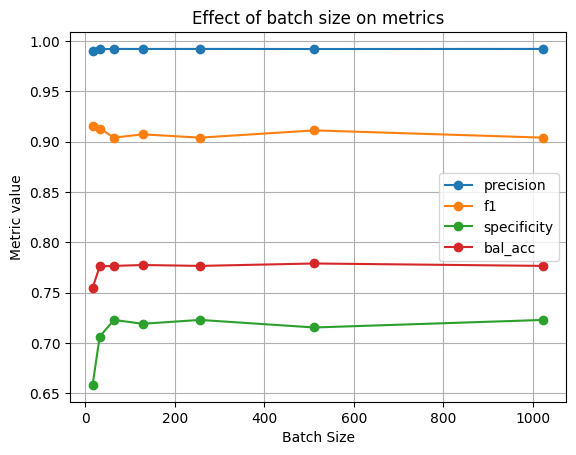

,Batch Size,precision,f1,specificity,bal_acc
0,16,0.990621,0.915475,0.658430,0.754678
1,32,0.991884,0.913104,0.706512,0.776215
2,64,0.992193,0.904070,0.722998,0.776661
3,128,0.992139,0.907360,0.719182,0.777556
4,256,0.992193,0.904070,0.722998,0.776661
5,512,0.992099,0.911276,0.715483,0.779056
6,1024,0.992193,0.904070,0.722998,0.776661


In [25]:
t_lstm_fcn_model_bt_test_results = sweep_batch_size_without_bg(LSTM_FCN_Classifier)
plot_metrics_vs_window(t_lstm_fcn_model_bt_test_results, title= "Effect of batch size on metrics", x_label_name="Batch Size")

In [26]:
# window_size = 10
# output_size = 5
# batch_size = 1024


# X_train, y_train, X_val, y_val, X_test, y_test = make_attendance_timeseries(attendence_encoded_df, cat_encoded_df, window_size=window_size, label_size=output_size)


# scaled_X_train, scaled_X_train_scaler = scale_selected_columns(X_train)
# scaled_X_val, scaled_X_val_scaler = scale_selected_columns(X_val)
# scaled_X_test, scaled_X_test_scaler = scale_selected_columns(X_test)

# train_dataset = TimeSeriesDataset(scaled_X_train, y_train)
# val_dataset   = TimeSeriesDataset(scaled_X_val,   y_val)
# test_dataset  = TimeSeriesDataset(scaled_X_test,  y_test)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
# test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [27]:
lstm_model_S_results = sweep_window_size_with_gb(LSTMClassifier_S)
# plot_metrics_vs_window(lstm_model_S_results, x_label_name="Window Size")

In [28]:
cnn_model_S_results = sweep_window_size_with_gb(CNNClassifier_S)
# plot_metrics_vs_window(cnn_model_S_results, x_label_name="Window Size")

In [29]:
lstm_fcn_model_results = sweep_window_size_with_gb(LSTM_FCN_Classifier)
# plot_metrics_vs_window(lstm_fcn_model_results, x_label_name="Window Size")

In [30]:
t_lstm_model_S_results = sweep_window_size_without_bg(LSTMClassifier_S)
# plot_metrics_vs_window(t_lstm_model_S_results, x_label_name="Window Size")

In [31]:
t_cnn_model_S_results = sweep_window_size_without_bg(CNNClassifier_S)
# plot_metrics_vs_window(t_cnn_model_S_results, x_label_name="Window Size")

In [32]:
t_lstm_fcn_model_results = sweep_window_size_without_bg(LSTM_FCN_Classifier)
# plot_metrics_vs_window(t_lstm_fcn_model_results, x_label_name="Window Size")

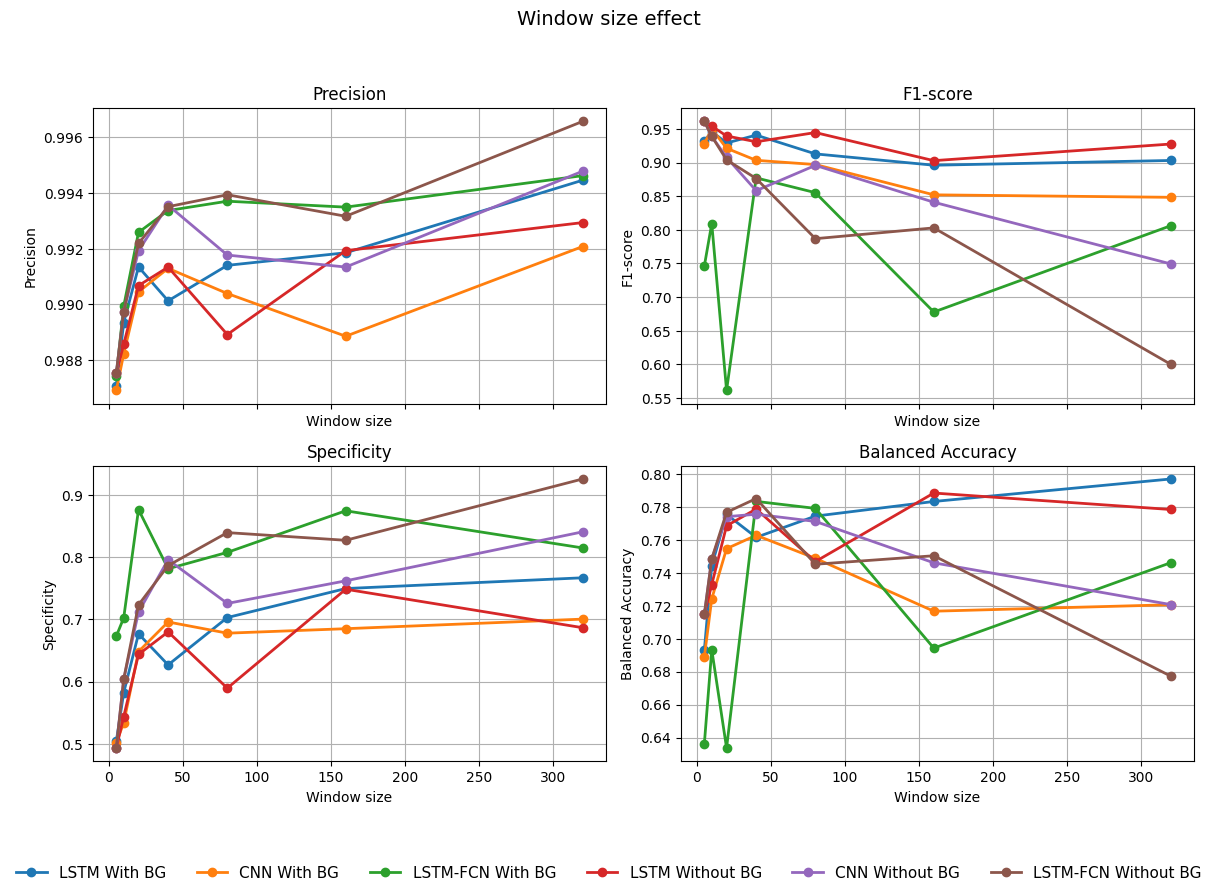

In [33]:
results_list = [lstm_model_S_results, cnn_model_S_results, lstm_fcn_model_results, t_lstm_model_S_results, t_cnn_model_S_results, t_lstm_fcn_model_results]
labels = ["LSTM With BG", "CNN With BG", "LSTM-FCN With BG", "LSTM Without BG", "CNN Without BG", "LSTM-FCN Without BG"]
title="Window size effect"

df_all = plot_metrics_2x2(results_list, labels=labels, title=title)


In [34]:
find_the_record_by_window(40, labels , results_list)

,Model,Precision,F1-Score,Specificity,Balanced Accuracy
0,LSTM With BG,0.990132,0.940849,0.626709,0.761474
1,CNN With BG,0.991299,0.903362,0.695654,0.762704
2,LSTM-FCN With BG,0.993376,0.877253,0.781114,0.783276
3,LSTM Without BG,0.991342,0.930971,0.679731,0.778631
4,CNN Without BG,0.993568,0.858215,0.795654,0.775486
5,LSTM-FCN Without BG,0.993514,0.876289,0.786171,0.784989


In [35]:
find_the_record_by_window(80, labels, results_list)

,Model,Precision,F1-Score,Specificity,Balanced Accuracy
0,LSTM With BG,0.991406,0.912922,0.702748,0.774350
1,CNN With BG,0.990394,0.897072,0.677658,0.748740
2,LSTM-FCN With BG,0.993711,0.855256,0.807407,0.779036
3,LSTM Without BG,0.988921,0.944646,0.589367,0.746766
4,CNN Without BG,0.991775,0.895840,0.725408,0.771118
5,LSTM-FCN Without BG,0.993943,0.786824,0.839148,0.745143


In [36]:
find_the_record_by_window(160, labels, results_list)

,Model,Precision,F1-Score,Specificity,Balanced Accuracy
0,LSTM With BG,0.991858,0.896072,0.749313,0.783234
1,CNN With BG,0.988859,0.852039,0.684838,0.716658
2,LSTM-FCN With BG,0.993498,0.677765,0.874198,0.694257
3,LSTM Without BG,0.991935,0.902861,0.748237,0.788352
4,CNN Without BG,0.991345,0.841047,0.761706,0.746014
5,LSTM-FCN Without BG,0.993170,0.802883,0.826818,0.750304


## Test

In [48]:
final_testing_results_40_days = final_testing(LSTM_FCN_Classifier,40)
final_testing_results_80_days = final_testing(LSTM_FCN_Classifier,80)
final_testing_results_160_days = final_testing(LSTM_FCN_Classifier,160)

rows = []

for keys, values in {
    "40": final_testing_results_40_days,
    "80": final_testing_results_80_days,
    "160": final_testing_results_160_days
}.items():

    rows.append({
        "Days": keys,
        "Precision": values["precision"],
        "F1": values["f1"],
        "Specificity": values["specificity"],
        "Balanced Accuracy": values["bal_acc"],
    })

final_testing_results_df = pd.DataFrame(rows)

final_testing_results_df

,Days,Precision,F1,Specificity,Balanced Accuracy
0,40,0.993290,0.883364,0.784513,0.789928
1,80,0.993773,0.859216,0.815157,0.785954
2,160,0.992990,0.652799,0.876592,0.681408
